# Metaheuristics 101: a first story

This notebook complements the
[Learn track](../learn/01-what-are-metaheuristics.html) — read that page
first for the "what and why"; this notebook tells the same story as code
you can run and change yourself. No prior optimization background is
assumed.

The story: one simple problem, three searches of increasing
sophistication — pure random guessing, then a search that improves one
point at a time, then a search that evolves a whole population — each a
few lines of `sezgi`, each on the exact same problem and budget so the
comparison at the end is fair.


## The problem: find the lowest point of a bowl

`sezgi.bbob(1, 2, 1)` is BBOB's Sphere function in 2 dimensions:
`f(x, y) = x^2 + y^2`, a perfect bowl with its lowest point at the origin.
Two dimensions is small enough to picture directly — every candidate is
just a 2D `x = (x, y)`, and "how good is this point" is just "how far is
it from the center". `problem` here is a native, compiled-in Rust handle
(like every `sezgi.bbob(...)` problem) rather than a `sezgi.Problem`
subclass, so its objective is not called directly from Python — only
through an algorithm's `.run()`, which is exactly what every search below
does. Every search below gets the same `budget=300` (BBOB function calls)
and the same `seed=0`.


In [1]:
import sezgi

problem = sezgi.bbob(1, 2, 1)  # f(x, y) = x^2 + y^2
budget, seed = 300, 0

print(f"problem: {type(problem)}")


problem: <class 'sezgi._sezgi.Problem'>


## Search 1: pure random guessing

The simplest possible strategy: pick a random point, remember it if it
beats the best point seen so far, repeat until the budget runs out. No
memory of *where* good points tend to be — every guess is independent of
every earlier one. `sezgi.RandomSearch` is exactly this (uniform
resampling every generation, no bias toward the current best):


In [2]:
random_result = sezgi.RandomSearch(pop_size=20).run(problem, budget=budget, seed=seed)
print(f"random search:   best_f={random_result.best_f:.6g} gap={random_result.gap:.6g}")


random search:   best_f=167.225 gap=0.0149251


## Search 2: improve one point at a time (local search / hill climbing)

A step up: keep ONE current point, look at a nearby point, and move there
only if it is better. This is called *hill climbing* (or local search) —
its `neighbor()` hook proposes one perturbed candidate, and the base
class's default `accept()` keeps whichever of {current, neighbor} the
engine's own replacer already decided was better (see
[Tutorial 4](../tutorials/04-population-and-local-search.html) for the full
mechanics). Unlike random search, EVERY step starts from the best point
found so far, instead of throwing that information away:


In [3]:
class HillClimb(sezgi.LocalSearch):
    '''neighbor(): perturb the current point by an independent uniform
    step in [-step, step] per coordinate.'''

    def __init__(self, step=0.3):
        self.step = step

    def neighbor(self, x, ctx):
        return [xi + (ctx.rng.next_f64() - 0.5) * 2 * self.step for xi in x]


hillclimb_result = HillClimb(step=0.3).run(problem, budget=budget, seed=seed)
print(f"hill climbing:   best_f={hillclimb_result.best_f:.6g} gap={hillclimb_result.gap:.6g}")


hill climbing:   best_f=167.212 gap=0.00262999


## Search 3: evolve a whole population

The most sophisticated of the three: keep a whole POPULATION of points
at once, each generation *selecting* better parents, *varying* them into
offspring, and *replacing* the population with the fittest mix — the
three-stage loop every population-based metaheuristic shares (see
[Anatomy of a population-based algorithm](../learn/02-anatomy-of-a-population-algorithm.html)).
`sezgi.GeneticAlgorithm` is a ready-made instance of exactly this shape —
no custom class needed for this one:


In [4]:
ga_result = sezgi.GeneticAlgorithm(pop_size=20).run(problem, budget=budget, seed=seed)
print(f"genetic algorithm: best_f={ga_result.best_f:.6g} gap={ga_result.gap:.6g}")


genetic algorithm: best_f=167.211 gap=0.00178671


## The three, side by side

Same problem, same budget, same seed for all three — only the search
strategy differs. The plot below re-runs each of the three at a few
increasing budgets (independent `.run()` calls, one per point plotted) to
show HOW each one closes the gap as it is given more evaluations, not
just where it lands at the end:


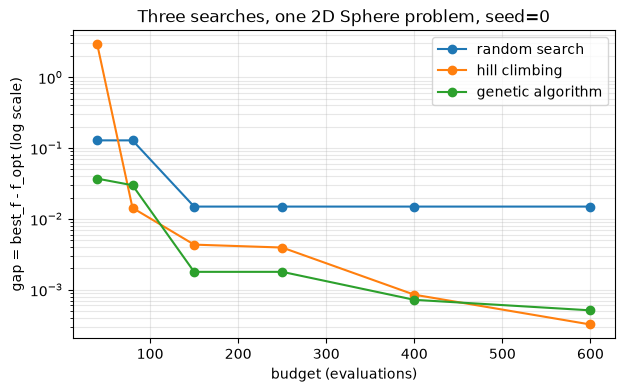

In [5]:
import matplotlib.pyplot as plt

budgets = [40, 80, 150, 250, 400, 600]
searches = {
    "random search": lambda b: sezgi.RandomSearch(pop_size=20).run(problem, budget=b, seed=seed),
    "hill climbing": lambda b: HillClimb(step=0.3).run(problem, budget=b, seed=seed),
    "genetic algorithm": lambda b: sezgi.GeneticAlgorithm(pop_size=20).run(problem, budget=b, seed=seed),
}

fig, ax = plt.subplots(figsize=(7, 4))
for name, run_at in searches.items():
    gaps = [max(run_at(b).gap, 1e-12) for b in budgets]  # floor for the log scale
    ax.plot(budgets, gaps, marker="o", label=name)

ax.set_yscale("log")
ax.set_xlabel("budget (evaluations)")
ax.set_ylabel("gap = best_f - f_opt (log scale)")
ax.set_title("Three searches, one 2D Sphere problem, seed=0")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.show()


Genetic algorithm and hill climbing both use information from earlier
evaluations to decide where to look next; random search never does — on
this easy, unimodal bowl, that difference shows up directly as a faster
drop in the plotted gap. A harder, more deceptive landscape can tell a
very different story, which is exactly why
[Comparing algorithms fairly](../learn/05-comparing-algorithms-fairly.html)
insists on testing across many problems and seeds before trusting a
ranking.


## Next

- [Learn track](../learn/01-what-are-metaheuristics.html) — the six-page
  introduction this notebook complements, with more diagrams and no code
  required.
- [Interactive quickstart](01-interactive-quickstart.html) — the
  class-first path in full, one `SolveResult` field at a time.
